In [36]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# Deep Learning Assignment 1
## Perceptron and Logistic Regression

**Name:** Harry Lyu

**Student ID:** hl4067

**Course:** COMSW4726 Deep Learning for Data Science

## 1. Data Preparation

The Forest Cover Type dataset contains environmental features used to predict forest cover types. The data will be split into 80% training data and 20% test data.Features will be standardized using statistics calculated only from the training set.

In [37]:
from sklearn.datasets import fetch_covtype

# Load the dataset. The first run requires an internet connection.
forest = fetch_covtype()
X_all = forest.data
y_all = forest.target
print("Original feature matrix:", X_all.shape)
print("Original cover types:", np.unique(y_all))

# Keep only cover types 1 and 2.
mask = np.isin(y_all, [1, 2])
X = X_all[mask]
y_original = y_all[mask]

# Encode type 1 as 0 and type 2 as 1.
y = (y_original == 2).astype(int)
print("\nBinary feature matrix:", X.shape)
print("Binary labels:", np.unique(y))

# Show the number of observations in each class.
class_counts = pd.DataFrame({
    "Cover type": [1, 2],
    "Binary label": [0, 1],
    "Observations": [(y == 0).sum(), (y == 1).sum()]})
display(class_counts)

Original feature matrix: (581012, 54)
Original cover types: [1 2 3 4 5 6 7]

Binary feature matrix: (495141, 54)
Binary labels: [0 1]


,Cover type,Binary label,Observations
0,1,0,211840
1,2,1,283301


### Train–Test Split and Feature Standardization

The data is split into 80% training data and 20% test data. Stratified sampling preserves approximately the same class proportions
in both sets. The fixed random seed makes the split reproducible. Features are standardized using the training-set means and standard
deviations. The same transformation is applied to the test set to avoid data leakage.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Learn from the training set only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

# Check
split_summary = pd.DataFrame({"Dataset": ["Training", "Test"],
                "Observations": [len(y_train), len(y_test)],
                "Class 0 proportion": [(y_train == 0).mean(), (y_test == 0).mean()],
                "Class 1 proportion": [(y_train == 1).mean(), (y_test == 1).mean()]})

display(split_summary.round(4))

Training set: (396112, 54)
Test set: (99029, 54)


,Dataset,Observations,Class 0 proportion,Class 1 proportion
0,Training,396112,0.4278,0.5722
1,Test,99029,0.4278,0.5722


## 2. Perceptron

This section implements the Perceptron using NumPy, with all 54 standardized features. Cover type 2 (label 1) is the positive class.

### Training Method

The weights and bias are initialized to zero. For each training observation, the model calculates a linear score: $z = w^\top x + b$. The predicted label is 1 if $z \geq 0$, and 0 otherwise. When the prediction is incorrect, the weights and bias are updated using:
$$
w \leftarrow w + \eta(y-\hat{y})x
$$

$$
b \leftarrow b + \eta(y-\hat{y})
$$
The learning rate is 0.01, and the maximum number of training epochs is 20. Training observations are shuffled before each epoch using a random generator initialized with seed 42. Training stops if an entire epoch contains no classification errors or if the maximum number of epochs is reached. The epoch limit prevents training from continuing indefinitely when the classes are not linearly separable. The trained model will be evaluated on the test set using accuracy, precision, recall, and F1-score.

In [ ]:
n_features = X_train_scaled.shape[1]
weights = np.zeros(n_features)
bias = 0.0
learning_rate = 0.01
max_epochs = 20
rng = np.random.default_rng(42)
errors_per_epoch = []
print("Number of weights:", len(weights))
print("Initial bias:", bias)

Number of weights: 54
Initial bias: 0.0


In [ ]:
# Reset
weights = np.zeros(n_features)
bias = 0.0
rng = np.random.default_rng(42)
errors_per_epoch = []
stop_reason = "Maximum number of epochs reached"

for epoch in range(max_epochs):
    mistakes = 0
    shuffled_indices = rng.permutation(len(y_train))

    for i in shuffled_indices:
        x_i = X_train_scaled[i]
        y_i = y_train[i]
        score = np.dot(x_i, weights) + bias
        prediction = 1 if score >= 0 else 0
        error = int(y_i) - prediction

        if error != 0:
            weights += learning_rate * error * x_i
            bias += learning_rate * error
            mistakes += 1
    errors_per_epoch.append(mistakes)

    print(f"Epoch {epoch + 1}/{max_epochs}: "
        f"{mistakes} training mistakes")

    if mistakes == 0:
        stop_reason = "No mistakes during an entire epoch"
        break

perceptron_weights = weights.copy()
perceptron_bias = float(bias)
print(len(errors_per_epoch))

Epoch 1/20: 123193 training mistakes
Epoch 2/20: 123547 training mistakes
Epoch 3/20: 122939 training mistakes
Epoch 4/20: 123691 training mistakes
Epoch 5/20: 123259 training mistakes
Epoch 6/20: 123654 training mistakes
Epoch 7/20: 123242 training mistakes
Epoch 8/20: 122878 training mistakes
Epoch 9/20: 123484 training mistakes
Epoch 10/20: 123179 training mistakes
Epoch 11/20: 123170 training mistakes
Epoch 12/20: 123226 training mistakes
Epoch 13/20: 122893 training mistakes
Epoch 14/20: 123846 training mistakes
Epoch 15/20: 123179 training mistakes
Epoch 16/20: 122870 training mistakes
Epoch 17/20: 123425 training mistakes
Epoch 18/20: 123450 training mistakes
Epoch 19/20: 123216 training mistakes
Epoch 20/20: 123457 training mistakes
20


### Perceptron Results and Decision Boundary

Training stopped after reaching the maximum of 20 epochs. No epoch had zero classification errors, so the zero-error stopping criterion was not met. The mistake counts recorded during training reflect predictions made while the weights were being updated. The evaluation below uses the final weights and bias to predict the held-out test set. Cover type 2 (label 1) is the positive class. Accuracy, precision, recall, and F1-score are calculated from the test-set confusion matrix counts.

In [ ]:
test_scores = X_test_scaled @ perceptron_weights + perceptron_bias
y_pred_perceptron = (test_scores >= 0).astype(int)

# Count true/false
tp = int(np.sum((y_test == 1) & (y_pred_perceptron == 1)))
tn = int(np.sum((y_test == 0) & (y_pred_perceptron == 0)))
fp = int(np.sum((y_test == 0) & (y_pred_perceptron == 1)))
fn = int(np.sum((y_test == 1) & (y_pred_perceptron == 0)))

assert tp + tn + fp + fn == len(y_test)

# Calculate metrics
accuracy = (tp + tn) / len(y_test)
precision = tp / (tp + fp) if tp + fp > 0 else 0.0
recall = tp / (tp + fn) if tp + fn > 0 else 0.0
f1 = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn > 0 else 0.0

perceptron_results = { "Model": "Perceptron", "Accuracy": accuracy, 
                      "Precision": precision, "Recall": recall, "F1-score": f1}

confusion_table = pd.DataFrame([[tn, fp], [fn, tp]],
                               index=["Actual 0 (Type 1)", "Actual 1 (Type 2)"],
                               columns=["Predicted 0", "Predicted 1"])

display(confusion_table)
display(pd.DataFrame([perceptron_results]).round(4))

,Predicted 0,Predicted 1
Actual 0 (Type 1),36079,6289
Actual 1 (Type 2),24418,32243


,Model,Accuracy,Precision,Recall,F1-score
0,Perceptron,0.6899,0.8368,0.5691,0.6774


### Decision Boundary: A Two-Dimensional Slice

The manually implemented Perceptron achieved a test accuracy of 0.6899, precision of 0.8368, recall of 0.5691, and F1-score of 0.6774. Its relatively high precision and lower recall indicate that many actual cover type 2 observations were missed.

The following plot shows a two-dimensional slice of the model trained on all 54 features. Elevation and Slope vary across the grid, while the remaining standardized features are fixed at zero, corresponding to their training-set means.

The points show the true labels of projected test observations. Because their other features are not fixed at the reference values, a point's background color does not necessarily indicate the full model's prediction for that observation. The reference values may also include fractional values for binary features, so this slice is an illustration rather than a set of actual forest observations.

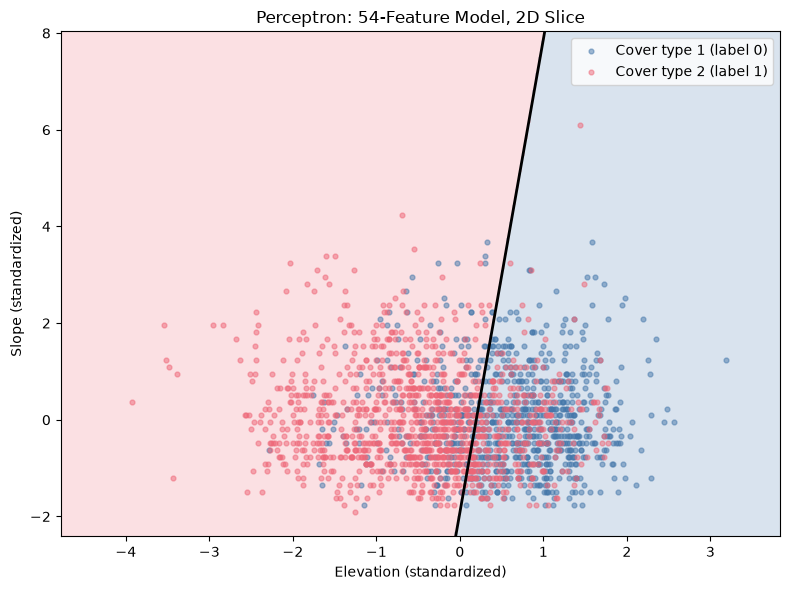

In [ ]:
# Select 2 features 
selected_features = ["Elevation", "Slope"]
feature_indices = [list(forest.feature_names).index(name)for name in selected_features]

X_train_2d = X_train_scaled[:, feature_indices]
X_test_2d = X_test_scaled[:, feature_indices]

# Build a grid 
lower = X_train_2d.min(axis=0) - 0.5
upper = X_train_2d.max(axis=0) + 0.5

xx, yy = np.meshgrid(np.linspace(lower[0], upper[0], 250), np.linspace(lower[1], upper[1], 250))

grid_full = np.zeros((xx.size, X_train_scaled.shape[1]))
grid_full[:, feature_indices[0]] = xx.ravel()
grid_full[:, feature_indices[1]] = yy.ravel()

# Use the existing full-model weights
slice_scores = (grid_full @ perceptron_weights + perceptron_bias).reshape(xx.shape)

slice_regions = (slice_scores >= 0).astype(int)

# Select test observations for display.
rng_plot = np.random.default_rng(42)
plot_indices = rng_plot.choice(len(y_test),size=min(2000, len(y_test)),replace=False)

fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(xx, yy, slice_regions, levels=[-0.5, 0.5, 1.5],
            colors=["#4477AA", "#EE6677"],alpha=0.2)

# only if
if slice_scores.min() < 0 < slice_scores.max():
    ax.contour(xx, yy, slice_scores,levels=[0],colors="black",linewidths=2)

else:
    print("No decision boundary crosses the displayed grid.")

for label, color, name in [(0, "#4477AA", "Cover type 1 (label 0)"),
                           (1, "#EE6677", "Cover type 2 (label 1)")]:
    indices = plot_indices[y_test[plot_indices] == label]
    ax.scatter( X_test_2d[indices, 0],X_test_2d[indices, 1],
               color=color, label=name, s=12, alpha=0.5)

ax.set_xlabel("Elevation (standardized)")
ax.set_ylabel("Slope (standardized)")
ax.set_title("Perceptron: 54-Feature Model, 2D Slice")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Logistic Regression

This section implements Logistic Regression using NumPy and all 54 standardized features. It uses the same training and test sets as the Perceptron.

The model calculates a linear score and converts it into the probability of label 1 using the sigmoid function:

$$
z = Xw + b
$$

$$
p = \frac{1}{1+\exp(-z)}
$$

Weights and bias are initialized to zero. Training minimizes the mean binary cross-entropy using full-batch gradient descent, without regularization.

For a training set with N observations, the gradients are:

$$
\nabla_w L = \frac{1}{N}X^\top(p-y)
$$

$$
\frac{\partial L}{\partial b} = \frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)
$$

The parameters are updated by subtracting the learning rate multiplied by the corresponding gradient.

The initial experiment uses a learning rate of 0.1 and a fixed budget of 1,000 gradient updates. Training loss will be recorded to assess the optimization behavior. Reaching the update limit does not by itself demonstrate convergence.

Predicted probabilities of at least 0.5 are assigned label 1 (cover type 2).

In [ ]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    probabilities = np.empty_like(z)
    positive = z >= 0
    probabilities[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
    exp_z = np.exp(z[~positive])
    probabilities[~positive] = exp_z / (1.0 + exp_z)
    return probabilities

logistic_weights = np.zeros(X_train_scaled.shape[1])
logistic_bias = 0.0
logistic_learning_rate = 0.1
logistic_max_epochs = 1000
logistic_loss_history = []

# Check
check_scores = np.array([-1000.0, 0.0, 1000.0])
print("Sigmoid check:", sigmoid(check_scores))
print("Number of weights:", len(logistic_weights))
print("Initial bias:", logistic_bias)

Sigmoid check: [0.  0.5 1. ]
Number of weights: 54
Initial bias: 0.0


In [ ]:
# Reset
logistic_weights = np.zeros(X_train_scaled.shape[1])
logistic_bias = 0.0
logistic_loss_history = []

n_train = len(y_train)

# Initial scores and loss before any updates.
train_scores = X_train_scaled @ logistic_weights + logistic_bias
initial_loss = np.mean(np.logaddexp(0.0, train_scores) - y_train * train_scores)
logistic_loss_history.append(float(initial_loss))

print(f"Initial training BCE: {initial_loss:.6f}")

for epoch in range(logistic_max_epochs):
    train_probabilities = sigmoid(train_scores)
    errors = train_probabilities - y_train

    gradient_w = X_train_scaled.T @ errors / n_train
    gradient_b = np.mean(errors)

    logistic_weights -= logistic_learning_rate * gradient_w
    logistic_bias -= logistic_learning_rate * gradient_b

    train_scores = (X_train_scaled @ logistic_weights + logistic_bias)
    training_loss = np.mean(np.logaddexp(0.0, train_scores) - y_train * train_scores)

    if not np.isfinite(training_loss):
        raise ValueError("Training loss is not finite. Check the learning rate "
            "and input data.")

    logistic_loss_history.append(float(training_loss))

    if (epoch + 1) % 100 == 0:
        print(f"Update {epoch + 1}/{logistic_max_epochs}: "
              f"training BCE = {training_loss:.6f}")

print("\nCompleted updates:", logistic_max_epochs)
print("Stopping reason: Fixed update budget reached")
print(f"Final training BCE: {logistic_loss_history[-1]:.6f}")

Initial training BCE: 0.693147
Update 100/1000: training BCE = 0.495886
Update 200/1000: training BCE = 0.483358
Update 300/1000: training BCE = 0.479315
Update 400/1000: training BCE = 0.477598
Update 500/1000: training BCE = 0.476786
Update 600/1000: training BCE = 0.476380
Update 700/1000: training BCE = 0.476170
Update 800/1000: training BCE = 0.476058
Update 900/1000: training BCE = 0.475997
Update 1000/1000: training BCE = 0.475964

Completed updates: 1000
Stopping reason: Fixed update budget reached
Final training BCE: 0.475964


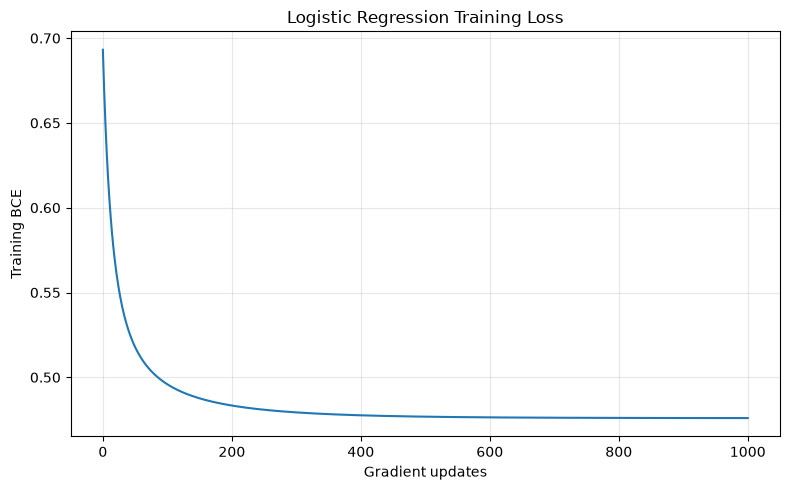

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(range(len(logistic_loss_history)), logistic_loss_history)

plt.xlabel("Gradient updates")
plt.ylabel("Training BCE")
plt.title("Logistic Regression Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Logistic Regression Results and Decision Boundary

The NumPy implementation completed 1,000 full-batch gradient updates with a learning rate of 0.1. Training BCE decreased from 0.693147 to 0.475964.

The training loss curve became flatter toward the end, indicating smaller improvements in the objective. Training stopped at the fixed update limit, rather than a convergence threshold.

The following evaluation uses the final weights and bias on the held-out test set. Predicted probabilities of at least 0.5 are assigned label 1, corresponding to cover type 2.

In [ ]:
# Predict probabilities using the manually trained model.
logistic_test_scores = (X_test_scaled @ logistic_weights + logistic_bias)

y_prob_logistic = sigmoid(logistic_test_scores)
y_pred_logistic = (y_prob_logistic >= 0.5).astype(int)

# Calculate confusion matrix counts.
tp_log = int(np.sum((y_test == 1) & (y_pred_logistic == 1)))
tn_log = int(np.sum((y_test == 0) & (y_pred_logistic == 0)))
fp_log = int(np.sum((y_test == 0) & (y_pred_logistic == 1)))
fn_log = int(np.sum((y_test == 1) & (y_pred_logistic == 0)))

assert tp_log + tn_log + fp_log + fn_log == len(y_test)

accuracy_log = (tp_log + tn_log) / len(y_test)

precision_log = (tp_log / (tp_log + fp_log)
    if tp_log + fp_log > 0 else 0.0)

recall_log = (tp_log / (tp_log + fn_log)
    if tp_log + fn_log > 0 else 0.0)

f1_log = (2 * tp_log / (2 * tp_log + fp_log + fn_log)
    if 2 * tp_log + fp_log + fn_log > 0 else 0.0)

# result
logistic_results = {"Model": "Logistic Regression", "Accuracy": accuracy_log,
                    "Precision": precision_log, "Recall": recall_log, "F1-score": f1_log}

logistic_confusion_table = pd.DataFrame([[tn_log, fp_log], [fn_log, tp_log]],
                                        index=["Actual 0 (Type 1)", "Actual 1 (Type 2)"],
                                        columns=["Predicted 0", "Predicted 1"])

display(logistic_confusion_table)
display(pd.DataFrame([logistic_results]).round(4))

,Predicted 0,Predicted 1
Actual 0 (Type 1),30256,12112
Actual 1 (Type 2),10209,46452


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.7746,0.7932,0.8198,0.8063


### Decision Boundary: A Two-Dimensional Slice

The NumPy Logistic Regression model achieved a test accuracy of 0.7746, precision of 0.7932, recall of 0.8198, and F1-score of 0.8063.

The plot below shows a slice of the model trained on all 54 features. Elevation and Slope vary, while the other standardized features are fixed at zero, corresponding to their training-set means. The black line marks a predicted probability of 0.5 for label 1.

The grid and projected test observations match the Perceptron plot. Because the observations have their own values for the remaining features, their background colors do not necessarily represent their actual full-model predictions. The mean reference values may include fractional values for binary features.

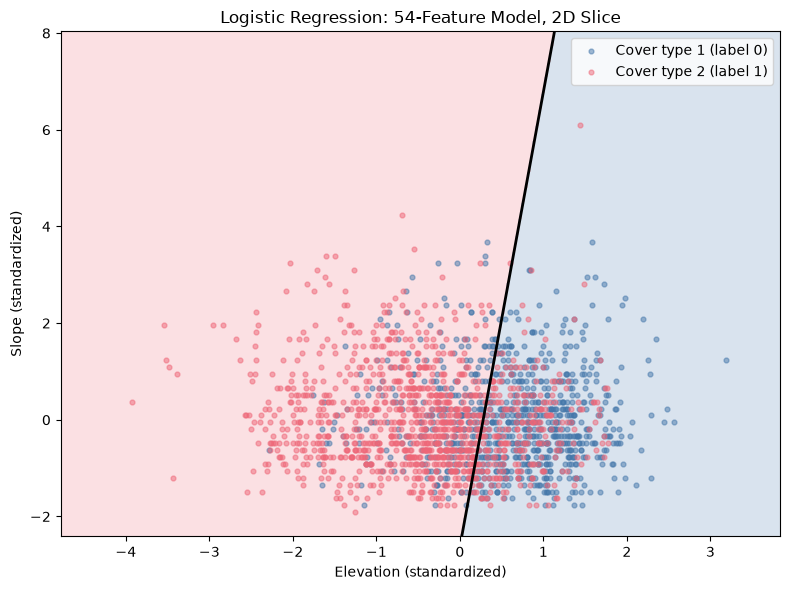

In [ ]:
# Logistic Regression: 54-Feature Model,
logistic_slice_scores = (grid_full @ logistic_weights + logistic_bias).reshape(xx.shape)

logistic_slice_probabilities = sigmoid(logistic_slice_scores)
logistic_slice_regions = (logistic_slice_probabilities >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(xx, yy, logistic_slice_regions, levels=[-0.5, 0.5, 1.5],
            colors=["#4477AA", "#EE6677"],alpha=0.2)

# A score of zero corresponds to a probability of 0.5.
if logistic_slice_scores.min() < 0 < logistic_slice_scores.max():
    ax.contour(xx, yy, logistic_slice_scores, levels=[0],
        colors="black", linewidths=2)
else:
    print("No decision boundary crosses the displayed grid.")

# Display
for label, color, name in [
    (0, "#4477AA", "Cover type 1 (label 0)"),
    (1, "#EE6677", "Cover type 2 (label 1)")]:

    indices = plot_indices[y_test[plot_indices] == label]
    ax.scatter(X_test_2d[indices, 0], X_test_2d[indices, 1],
               color=color, label=name, s=12, alpha=0.5)

ax.set_xlabel("Elevation (standardized)")
ax.set_ylabel("Slope (standardized)")
ax.set_title("Logistic Regression: 54-Feature Model")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Binary Cross-Entropy (BCE)

The test BCE evaluates the probabilities produced by the NumPy Logistic Regression model using all 54 features.

$$
L = -\frac{1}{N}\sum_{i=1}^{N}
\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]
$$

Here, $y_i$ is the true label and $p_i$ is the predicted probability of cover type 2 (label 1). Lower BCE indicates better probability predictions on the same test set.

The calculation uses the numerically stable, equivalent expression based on the linear scores $z_i$:

$$
L = \frac{1}{N}\sum_{i=1}^{N}
\left[\log(1+\exp(z_i))-y_i z_i\right]
$$

The Perceptron does not directly provide probability estimates, so its BCE is not reported.

The following probability-loss curves illustrate the loss for an individual observation with true label 0 or 1. They are separate from the training-loss curve shown earlier.

In [ ]:
# Calculate test scores using the manually trained model.
logistic_test_scores = (X_test_scaled @ logistic_weights + logistic_bias)
y_prob_logistic = sigmoid(logistic_test_scores)

# Mean test BCE, calculated directly from the linear scores.
bce_logistic = float(np.mean(np.logaddexp(0.0, logistic_test_scores) - y_test * logistic_test_scores))
eps = np.finfo(float).eps
p_safe = np.clip(y_prob_logistic, eps, 1 - eps)

bce_probability = float(-np.mean(
    y_test * np.log(p_safe)
    + (1 - y_test) * np.log(1 - p_safe)))

print(f"Training BCE:             {logistic_loss_history[-1]:.6f}")
print(f"Test BCE (score formula): {bce_logistic:.6f}")
print(f"Test BCE (probabilities): {bce_probability:.6f}")
print("Results approximately match:", np.isclose(bce_logistic, bce_probability))

Training BCE:             0.475964
Test BCE (score formula): 0.478253
Test BCE (probabilities): 0.478253
Results approximately match: True


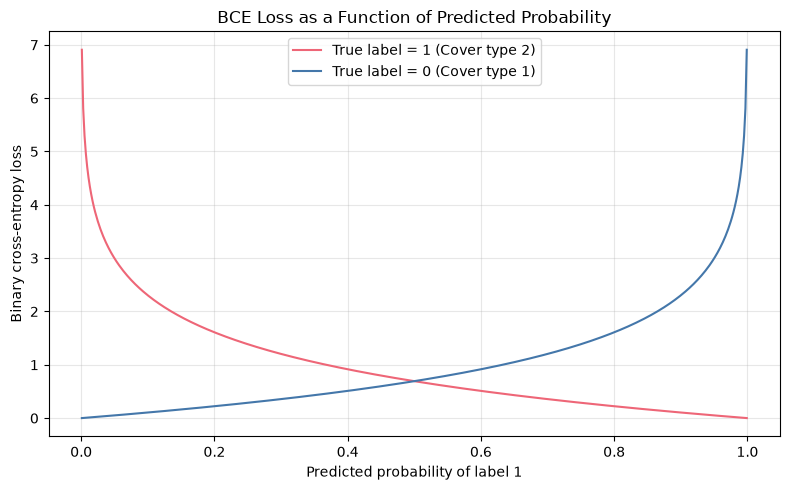

In [ ]:
# BCE Loss as a Function of Predicted Probability
p_values = np.linspace(0.001, 0.999, 500)

loss_label_1 = -np.log(p_values)
loss_label_0 = -np.log(1 - p_values)

plt.figure(figsize=(8, 5))

plt.plot(p_values, loss_label_1, label="True label = 1 (Cover type 2)", color="#EE6677")
plt.plot(p_values, loss_label_0, label="True label = 0 (Cover type 1)", color="#4477AA")

plt.xlabel("Predicted probability of label 1")
plt.ylabel("Binary cross-entropy loss")

plt.title("BCE Loss as a Function of Predicted Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Model Comparison
Both models are evaluated on the same test set using all 54 standardized features. Logistics Regression has higher accuracy, precision, recall, and F1-score indicate better classification performance. BCE is reported only for Logistic Regression because the Perceptron does not directly provide probability estimates.

In [ ]:
comparison = pd.DataFrame([perceptron_results,
                           logistic_results]).set_index("Model")

comparison["Test BCE"] = [np.nan, bce_logistic]
comparison_display = comparison.copy()

for column in comparison_display.columns:
    comparison_display[column] = comparison_display[column].apply(
        lambda value: "N/A" if pd.isna(value) else f"{value:.4f}")

display(comparison_display)

,Accuracy,Precision,Recall,F1-score,Test BCE
Model,,,,,
Perceptron,0.6899,0.8368,0.5691,0.6774,N/A
Logistic Regression,0.7746,0.7932,0.8198,0.8063,0.4783


### Discussion

Both models trained using the same 54 standardized features. The same held-out test set was also used for evaluation, so the results are directly comparable under this experiment setup.

Logistic Regression reached an accuracy of 77.46%, while the Perceptron achieved 68.99%. This is about an 8.47 percentage point difference. Logistic Regression also had better recall and F1-score overall. The Perceptron, however, had higher precision, with 0.8368 compared to 0.7932 for Logistic Regression. This mainly come from the different types of errors made by the two models. The Perceptron miss 24,418 observations that were actually cover type 2, while Logistic Regression missed only 10,209. In the other hand, Logistic Regression produced more false positives, 12,112 compared with 6,289 from the Perceptron. So basically, Logistic Regression was more willing to classify observations as positive, which improved recall but lowered precision somewhat.

The Perceptron stopped after reaching the maximum of 20 epochs, and it never reached an epoch with zero classification errors. Logistic Regression was trained for 1,000 full-batch gradient updates. During training, its BCE decreased from 0.693147 to 0.475964. The loss was still decreasing near the end, although the changes became much smaller. Because of this, it would probably be too strong to say that either model fully converged just based on the stopping rule. For Logistic Regression, the test BCE is 0.478253, which is only slightly higher than the training BCE. At least for that particular train-test split, the differences between training and test loss is fairly small. Still, this result does not necessarily mean that the model would perform equally well on another dataset or another geographic region.

The decision-boundary plots for the two models also look fairly similar. However, these plots only show two-dimensional slices of models that actually uses 54 features. All of the other standardized features were fixed at zero when making the plots. Therefore, similar-looking boundary in the figures does not mean that the two models make the same predictions in the real test observations, where the remaining feature values are different.

## 6. Conclusion

For this train-test split and the selected training settings, Logistic Regression performed better in terms of accuracy, recall, and F1-score, while the Perceptron produced higher precision. ADifference is that Logistic Regression outputs probabilities, which makes it possible to evaluate the model use binary cross-entropy in addition that the classification metrics. The results shows that even though both methods are linear classifiers, their performance can still be quite different because they use different objectives and learning procedures.

Overall, Logistic Regression works better for this experiment, especially when identifying more of the actual cover type 2 observations. However, these results are limited to the selected cover types, parameter settings, and random train-test split. More validation are needed before making a broader conclusion about which method performs better in general.